### Fitting of a Gaussian Process Regression model (GP) to option price data
We will consider European option prices generated from the Black-Scholes model

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
from sklearn import gaussian_process
from sklearn.gaussian_process.kernels import RBF
import scipy.stats as st

#### Black-Scholes model parameters

In [ ]:
def bsformula(cp, s, k, rf, t, v, div):
    """ 
    Price an option using the Black-Scholes model
    cp: +1/-1 for call/put
    s: initial stock price
    k: strike price
    t: expiration time
    v: volatility
    rf: risk-free rate
    div: dividend
    """
    d1 = (np.log(s/k)+(rf-div+0.5*v*v)*t)/(v*np.sqrt(t))
    d2 = d1 - v*np.sqrt(t)

    optprice = (cp*s*np.exp(-div*t)*st.norm.cdf(cp*d1)) - (cp*k*np.exp(-rf*t)*st.norm.cdf(cp*d2))
    delta = cp*st.norm.cdf(cp*d1)
    vega  = s*np.sqrt(t)*st.norm.pdf(d1)
    return optprice, delta, vega

#### GP Call pricer

In [8]:
r  = 0.0002  # risk-free rate
S  = 100     # Underlying spot
KC = 130     # Call strike
KP = 70      # Put strike
sigma = 0.4  # implied volatility
T = 2.0      # Time to maturity

lb = 0.001           # lower bound on domain
ub = 300             # upper bound on domain
training_number = 5  # Number of training samples
testing_number = 100 # Number of testing samples

call = lambda x: bsformula(1, lb+(ub-lb)*x, KC, r, T, sigma, 0)[0]
put = lambda x: bsformula(-1, lb+(ub-lb)*x, KP, r, T, sigma, 0)[0]

train_x_1 = np.array(np.linspace(0, 1, training_number), dtype='float32').reshape(training_number, 1)
train_y_1 = [call(S) for S in train_x_1]
    
test_x_1 = np.array(np.linspace(0, 1, testing_number), dtype='float32').reshape(testing_number, 1)
test_y_1 = [call(S) for S in test_x_1]

In [17]:
train_x_1.flatten()

array([0.  , 0.25, 0.5 , 0.75, 1.  ], dtype=float32)

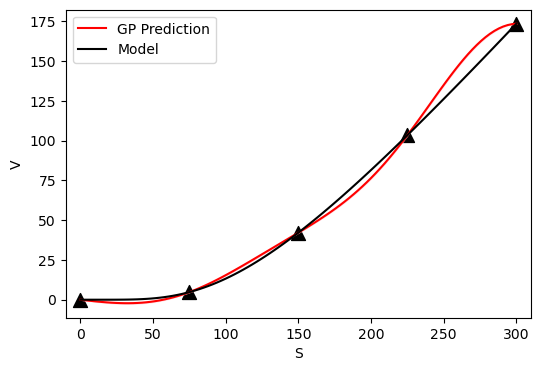

In [22]:
sk_kernel = RBF(length_scale=1, length_scale_bounds=(1e-05, 1000.0))
gp = gaussian_process.GaussianProcessRegressor(kernel=sk_kernel, n_restarts_optimizer=20)
gp.fit(train_x_1, train_y_1)

y_pred_1, sigma_1 = gp.predict(test_x_1, return_std=True)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(lb + (ub - lb) * test_x_1.flatten(), y_pred_1, color='red', label='GP Prediction')
ax.plot(lb + (ub - lb) * test_x_1.flatten(), test_y_1, color='black', label='Model')
ax.scatter(lb + (ub - lb) * train_x_1.flatten(), train_y_1, color='black', marker='^', s=100)
ax.fill_between(lb + (ub - lb) * test_x_1.flatten(), 
                (y_pred_1.T - 2*sigma_1).flatten(), 
                (y_pred_1.T + 2*sigma_1).flatten(),
                color='pink', 
                alpha=0.5)
ax.legend()
ax.set_xlim(lb-10, ub+10)
ax.set_xlabel('S')
ax.set_ylabel('V')
plt.show()

#### GP Put Pricer